## Deep Learning, DL Models, and Applications

```python
# Task 3: Vectorized Convolutional Forward Pass via im2col
# Transformation from Scratch
# ● Objective: Understand the mechanics of spatial feature extractors by implementing
# vectorized convolutional layers optimized for high-performance matrix multiplications.
# ● Required Tech Stack: Pure NumPy, Python 3.10+, SciPy.
# ● Task Description: Students must implement a 2D convolutional layer supporting arbitrary
# padding, strides, and input/output channels from scratch. They are required to write an
# im2col matrix helper to reshape the input tensor into a unified 2D matrix, transforming
# sliding window convolutions into a single dot-product operation.
```

In [57]:
#Step 1: Import Libraries
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [58]:
#Step 2: Create a Sample Input
X = np.random.rand(1, 3, 5, 5)

print(X.shape)

(1, 3, 5, 5)


In [59]:
#Step 3: Create Filters
filters = np.random.rand(2,3,3,3)

print(filters.shape)

(2, 3, 3, 3)


In [60]:
#Step 4: Padding Function
def add_padding(X, pad):

    return np.pad(
        X,
        ((0,0),(0,0),(pad,pad),(pad,pad)),
        mode='constant'
    )


In [61]:
X_pad = add_padding(X,1)

print(X_pad.shape)

(1, 3, 7, 7)


In [62]:
#Step 5: im2col Function
def im2col(X, kernel_size, stride):

    N,C,H,W = X.shape

    out_h = (H-kernel_size)//stride + 1
    out_w = (W-kernel_size)//stride + 1

    cols = []

    for i in range(out_h):
        for j in range(out_w):

            patch = X[
                :,
                :,
                i*stride:i*stride+kernel_size,
                j*stride:j*stride+kernel_size
            ]

            cols.append(patch.reshape(N,-1))

    cols = np.concatenate(cols,axis=0)

    return cols

In [63]:
cols = im2col(X_pad,3,1)

print(cols.shape)

(25, 27)


In [64]:
#Step 6: Convolution Function
def conv2d(X, filters, stride=1, padding=0):

    X = add_padding(X,padding)

    kernel = filters.shape[2]

    cols = im2col(X,kernel,stride)

    filter_col = filters.reshape(filters.shape[0],-1)

    output = cols @ filter_col.T

    N = X.shape[0]

    out_h = (X.shape[2]-kernel)//stride +1
    out_w = (X.shape[3]-kernel)//stride +1

    output = output.reshape(
        N,
        out_h,
        out_w,
        filters.shape[0]
    )

    output = output.transpose(0,3,1,2)

    return output

In [65]:
#Step 7: Test
output = conv2d(
    X,
    filters,
    stride=1,
    padding=1
)

print(output.shape)

(1, 2, 5, 5)


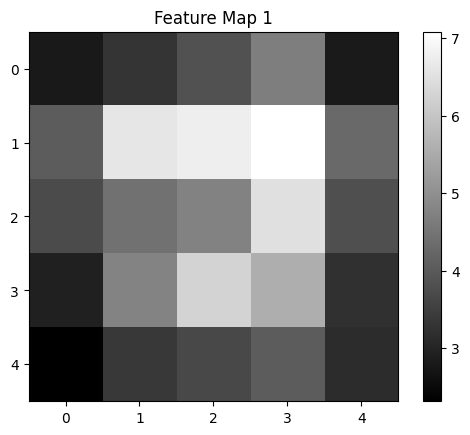

In [66]:
#Step 8: Display Output
plt.imshow(output[0,0], cmap="gray")
plt.title("Feature Map 1")
plt.colorbar()
plt.show()


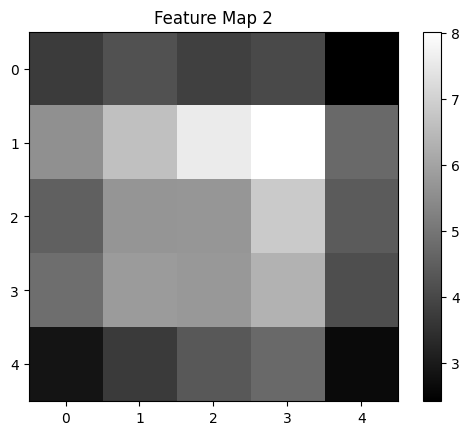

In [67]:
plt.imshow(output[0,1], cmap="gray")
plt.title("Feature Map 2")
plt.colorbar()
plt.show()